<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/flowassurance/hydrate_wax_and_water_margin_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hydrate, wax, and water margin screening with NeqSim

This notebook turns a preliminary three-case screen into a reproducible flow-assurance
workflow using current NeqSim thermodynamics, flow-assurance utilities, standards, process
objects, and measurement devices.

## Audience, prerequisites, and learning objectives

**Audience:** process, pipeline, production, and flow-assurance engineers who understand
phase equilibrium and want a transparent screening workflow.

**Prerequisites:** Python basics; familiarity with pressure, temperature, phase equilibrium,
and the distinction between screening and design.

After completing the notebook, you can:

1. build wet-gas, dry-gas, and waxy-condensate models for different screening questions;
2. calculate hydrate equilibrium temperature with SRK-CPA;
3. calculate water dew point with NeqSim's ISO 18453 implementation;
4. generate monotonic wax curves with `WaxCurveCalculator`;
5. map hydrate risk along a pressure-temperature profile;
6. embed a hydrate analyser in a `ProcessSystem`;
7. evaluate heating and MEG mitigation options with explicit engineering checks.

## Preservation checklist

The original notebook contained four substantive example groups:

1. the six-component SRK natural-gas definition;
2. the three operating cases named **warm export**, **normal export**, and **cold restart**;
3. hydrate, wax, water-dew-point, and density margins;
4. one grouped bar chart in which negative margin flags risk.

All four are retained and integrated. The original chart is preserved in recognizable form
with recalculated NeqSim results, explicit units, accessible colors, and interpretation.
Six additional technical figures are added; none replaces the previous visual.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [2]:
import hashlib
import importlib.metadata
import json
import math
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch
from neqsim import jneqsim


plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

java_version = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            importlib.metadata.version("neqsim"),
            platform.python_version(),
            java_version,
        ],
    }
)
runtime_table

Out[2]: 
  Runtime                               Version
0  NeqSim                                3.16.0
1  Python                               3.12.13
2    Java  openjdk version "17.0.19" 2026-04-21


## 1. Engineering context and decision boundary

Hydrate formation, wax precipitation, and free-water dropout can all threaten restart and
transport, but they are different phenomena. A single temperature threshold is therefore
unsafe. This notebook deliberately uses three fluid representations:

- a wet SRK-CPA gas with free water for hydrate equilibrium;
- a trace-water gas evaluated with ISO 18453 for water dew point;
- a characterized condensate with a C9+ fraction for wax precipitation.

Results are screening evidence. Detailed design also needs representative samples, tuned
models, transient heat transfer, deposition kinetics, chemical performance, uncertainty,
and operating procedures.

## 2. Margin definitions

For mechanism $k$, the operating margin is:

$$
M_k=T_{op}-T_{limit,k}
$$

Here $T_{op}$ is operating temperature in °C and $T_{limit,k}$ is the calculated hydrate
equilibrium temperature, water dew point, or wax appearance temperature at the same
pressure. A positive value is on the warm side of the threshold. A negative value is a
thermodynamic risk flag, not a deposition-rate prediction.

## 3. Governing thermodynamics and validity limits

Hydrate equilibrium requires equal water fugacity between the water-rich and hydrate
phases:

$$
f_w^{fluid}=f_w^{hydrate}
$$

Water dew point is the temperature where the gas becomes saturated with water at fixed
pressure. Wax appearance is the highest temperature at which a solid wax phase becomes
stable. `WaxCurveCalculator` evaluates flashes from high to low temperature and enforces a
nondecreasing wax fraction as temperature falls.

All pressures are absolute bar (`bara`), temperatures are °C, densities are kg/m³, mass
flows are kg/h, and wax fractions are wt%. Equilibrium results do not include kinetics,
wall-temperature gradients, shear removal, emulsions, or inhibitor transport.

## 4. Supported NeqSim classes used

- `SystemSrkEos`: preserves the original dry-gas property example.
- `SystemSrkCPAstatoil`: represents water-hydrocarbon association for hydrate calculations.
- `ThermodynamicOperations`: performs TP, hydrate, inhibitor, and hydrate-phase flashes.
- `Standard_ISO18453`: calculates natural-gas water dew point from water content.
- `HydrateRiskMapper`: evaluates a pressure-temperature profile and classifies risk.
- `WaxCurveCalculator`: produces a monotonic wax fraction curve and WAT.
- `Stream`, `ProcessSystem`, and `HydrateEquilibriumTemperatureAnalyser`: demonstrate how
  the thermodynamic calculation becomes a reusable process-monitoring workflow.

In [3]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemSrkCPA = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)
HydrateRiskMapper = (
    jneqsim.pvtsimulation.flowassurance.HydrateRiskMapper
)
WaxCurveCalculator = (
    jneqsim.pvtsimulation.flowassurance.WaxCurveCalculator
)
StandardISO18453 = (
    jneqsim.standards.gasquality.Standard_ISO18453
)
NeqSimDataBase = jneqsim.util.database.NeqSimDataBase
Stream = jneqsim.process.equipment.stream.Stream
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
HydrateAnalyser = (
    jneqsim.process.measurementdevice.HydrateEquilibriumTemperatureAnalyser
)

In [4]:
gas_composition = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.86,
    "ethane": 0.07,
    "propane": 0.03,
    "n-butane": 0.01,
}

cases = pd.DataFrame(
    {
        "case": [
            "warm export",
            "normal export",
            "cold restart",
        ],
        "distance_km": [0.0, 50.0, 100.0],
        "pressure_bara": [80.0, 70.0, 60.0],
        "temperature_C": [35.0, 18.0, 6.0],
    }
)

composition_table = pd.DataFrame(
    {
        "Component": list(gas_composition),
        "Mole fraction [-]": list(gas_composition.values()),
    }
)

display(composition_table)
display(cases)

,Component,Mole fraction [-]
0,nitrogen,0.01
1,CO2,0.02
2,methane,0.86
3,ethane,0.07
4,propane,0.03
5,n-butane,0.01


,case,distance_km,pressure_bara,temperature_C
0,warm export,0.0,80.0,35.0
1,normal export,50.0,70.0,18.0
2,cold restart,100.0,60.0,6.0


In [5]:
case_basis = {
    "gas_composition": gas_composition,
    "cases": cases.to_dict(orient="records"),
    "hydrate_free_water_mol": 0.03,
    "water_content_umol_per_mol": 60.0,
    "wax_model": "Pedersen",
}

case_fingerprint = hashlib.sha256(
    json.dumps(
        case_basis,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()

print(f"Composition sum: {sum(gas_composition.values()):.12f}")
print(f"Case fingerprint: {case_fingerprint}")

Composition sum: 1.000000000000
Case fingerprint: 82589e1f718e00109b0f06bb5285d4093919bda7589644569286132236468634


The six gas components and the three named operating cases are unchanged from the original
example. The added distance coordinate turns the three cases into a simple pipeline/restart
profile. A SHA-256 fingerprint makes later comparisons traceable.

In [6]:
def build_original_gas(
    temperature_c=25.0,
    pressure_bara=60.0,
):
    fluid = SystemSrkEos(
        temperature_c + 273.15,
        pressure_bara,
    )

    for component_name, mole_fraction in gas_composition.items():
        fluid.addComponent(
            component_name,
            mole_fraction,
        )

    fluid.setMixingRule("classic")
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


def build_hydrate_fluid(
    pressure_bara,
    temperature_c=10.0,
):
    fluid = SystemSrkCPA(
        temperature_c + 273.15,
        pressure_bara,
    )

    for component_name, mole_fraction in gas_composition.items():
        fluid.addComponent(
            component_name,
            mole_fraction,
        )

    fluid.addComponent("water", 0.03)
    fluid.setMixingRule(10)
    fluid.setHydrateCheck(True)
    return fluid


def build_trace_water_gas(
    water_umol_per_mol=60.0,
):
    fluid = SystemSrkCPA(
        273.15,
        70.0,
    )

    for component_name, mole_fraction in gas_composition.items():
        fluid.addComponent(
            component_name,
            mole_fraction,
        )

    fluid.addComponent(
        "water",
        water_umol_per_mol * 1.0e-6,
    )
    fluid.setMixingRule(10)
    fluid.init(0)
    fluid.init(1)
    return fluid

In [7]:
def build_waxy_condensate():
    NeqSimDataBase.setCreateTemporaryTables(True)

    try:
        fluid = SystemSrkEos(
            303.15,
            50.0,
        )
        light_components = {
            "CO2": 0.018,
            "nitrogen": 0.333,
            "methane": 96.702,
            "ethane": 1.773,
            "propane": 0.496,
            "i-butane": 0.099,
            "n-butane": 0.115,
            "i-pentane": 0.004,
            "n-pentane": 0.024,
            "n-heptane": 0.324,
        }

        for component_name, amount in light_components.items():
            fluid.addComponent(
                component_name,
                amount,
            )

        fluid.addPlusFraction(
            "C9",
            0.095,
            0.207,
            0.8331,
        )
        fluid.getCharacterization().characterisePlusFraction()
        fluid.getWaxModel().addTBPWax()
        fluid.createDatabase(True)
        fluid.setMixingRule(2)
        fluid.setWaxModelType("Pedersen")
        fluid.addSolidComplexPhase("wax")
        fluid.setMultiphaseWaxCheck(True)
        fluid.setMultiPhaseCheck(True)
        fluid.init(0)
        fluid.init(1)
        return fluid
    finally:
        NeqSimDataBase.setCreateTemporaryTables(False)

The waxy-condensate basis is synthetic and documented. The C9+ fraction is characterized
before the Pedersen wax phase is created. Temporary database tables are enabled only during
characterization and are disabled in a `finally` block. This ordering is required for a
stable, reproducible current API workflow.

In [8]:
density_rows = []

for operating_case in cases.itertuples(index=False):
    fluid = build_original_gas(
        temperature_c=float(operating_case.temperature_C),
        pressure_bara=float(operating_case.pressure_bara),
    )
    density_rows.append(
        {
            "Case": operating_case.case,
            "Temperature [°C]": operating_case.temperature_C,
            "Pressure [bara]": operating_case.pressure_bara,
            "Gas density [kg/m³]": fluid.getDensity("kg/m3"),
            "Compressibility factor [-]": fluid.getZ(),
        }
    )

density_table = pd.DataFrame(density_rows)
density_table

Out[8]: 
            Case  ...  Compressibility factor [-]
0    warm export  ...                    0.853597
1  normal export  ...                    0.831405
2   cold restart  ...                    0.824288

[3 rows x 5 columns]


The original SRK gas is retained for density and compressibility. Hydrate and water-dew-point
calculations use water-aware models because the classic SRK gas alone cannot represent those
mechanisms rigorously.

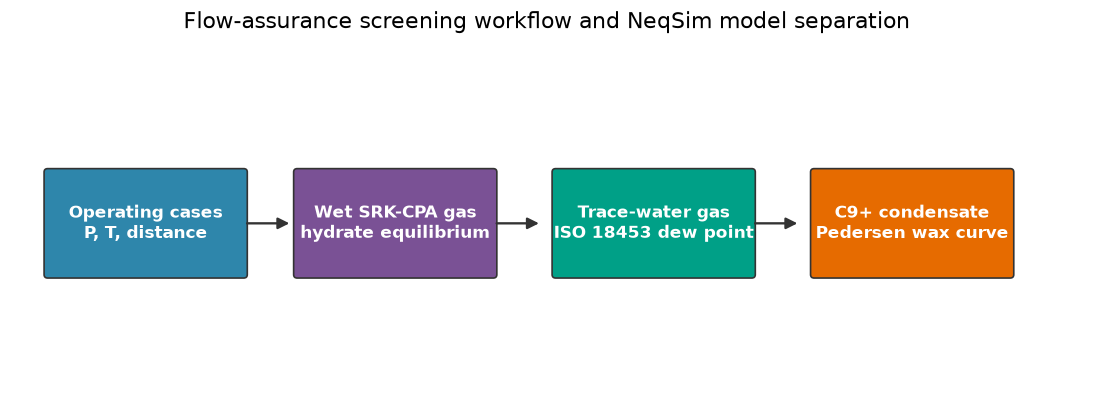

In [9]:
figure, axis = plt.subplots(figsize=(11.5, 3.7))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

boxes = [
    (
        0.4,
        "Operating cases\nP, T, distance",
        "#2E86AB",
    ),
    (
        3.2,
        "Wet SRK-CPA gas\nhydrate equilibrium",
        "#7A5195",
    ),
    (
        6.1,
        "Trace-water gas\nISO 18453 dew point",
        "#00A087",
    ),
    (
        9.0,
        "C9+ condensate\nPedersen wax curve",
        "#E66B00",
    ),
]

for x_position, label, color in boxes:
    box = FancyBboxPatch(
        (x_position, 1.35),
        2.2,
        1.2,
        boxstyle="round,pad=0.04",
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.0,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 1.1,
        1.95,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        weight="bold",
    )

for x_start in [2.6, 5.4, 8.3]:
    arrow = FancyArrowPatch(
        (x_start, 1.95),
        (x_start + 0.55, 1.95),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.4,
        color="#333333",
    )
    axis.add_patch(arrow)

axis.set_title(
    "Flow-assurance screening workflow and NeqSim model separation",
    fontsize=13,
    pad=12,
)
plt.show()

**Interpretation.** The workflow begins with one operating profile, but each mechanism is
evaluated with a fluid model appropriate to its physics. Combining the resulting margins is
useful for screening; treating the three threshold temperatures as properties of one
interchangeable fluid would not be.

## 5. Hydrate equilibrium temperatures

`hydrateFormationTemperature()` changes a fresh fluid clone to its hydrate equilibrium
temperature at fixed pressure. Fresh objects prevent a calculation at one pressure from
contaminating the next case.

In [10]:
hydrate_temperature_cache = {}


def hydrate_temperature_c(pressure_bara):
    pressure_key = float(pressure_bara)

    if pressure_key not in hydrate_temperature_cache:
        fluid = build_hydrate_fluid(
            pressure_bara=pressure_key,
        )
        operations = ThermodynamicOperations(fluid)
        operations.hydrateFormationTemperature()
        hydrate_temperature_cache[pressure_key] = (
            fluid.getTemperature("C")
        )

    return hydrate_temperature_cache[pressure_key]


hydrate_rows = []

for operating_case in cases.itertuples(index=False):
    equilibrium_c = hydrate_temperature_c(
        operating_case.pressure_bara
    )
    hydrate_rows.append(
        {
            "Case": operating_case.case,
            "Pressure [bara]": operating_case.pressure_bara,
            "Operating temperature [°C]": (
                operating_case.temperature_C
            ),
            "Hydrate equilibrium temperature [°C]": equilibrium_c,
            "Hydrate margin [°C]": (
                operating_case.temperature_C - equilibrium_c
            ),
        }
    )

hydrate_table = pd.DataFrame(hydrate_rows)
hydrate_table

Out[10]: 
            Case  ...  Hydrate margin [°C]
0    warm export  ...            16.132178
1  normal export  ...            -0.036903
2   cold restart  ...           -11.013888

[3 rows x 5 columns]


The warm case is safely above equilibrium. The normal case sits essentially on the hydrate
boundary, while the cold restart is well inside the equilibrium hydrate region. Actual
blockage also requires water availability, nucleation, growth, residence time, and a
transport mechanism.

## 6. Water dew point with ISO 18453

The water screen assumes 60 µmol/mol water in the gas. `Standard_ISO18453` internally uses
NeqSim's GERG-water model and reports the dew point at each pressure. This is a trace-water
specification calculation, distinct from the free-water hydrate calculation.

In [11]:
water_dew_point_cache = {}


def water_dew_point_c(
    pressure_bara,
    water_umol_per_mol=60.0,
):
    cache_key = (
        float(pressure_bara),
        float(water_umol_per_mol),
    )

    if cache_key not in water_dew_point_cache:
        fluid = build_trace_water_gas(
            water_umol_per_mol=water_umol_per_mol,
        )
        standard = StandardISO18453(fluid)
        standard.setPressure(float(pressure_bara))
        standard.calculate()
        water_dew_point_cache[cache_key] = standard.getValue(
            "dewPointTemperature",
            "C",
        )

    return water_dew_point_cache[cache_key]


water_rows = []

for operating_case in cases.itertuples(index=False):
    dew_point_c = water_dew_point_c(
        operating_case.pressure_bara
    )
    water_rows.append(
        {
            "Case": operating_case.case,
            "Pressure [bara]": operating_case.pressure_bara,
            "Water content [µmol/mol]": 60.0,
            "Water dew point [°C]": dew_point_c,
            "Water margin [°C]": (
                operating_case.temperature_C - dew_point_c
            ),
        }
    )

water_table = pd.DataFrame(water_rows)
water_table

Out[11]: 
            Case  Pressure [bara]  ...  Water dew point [°C]  Water margin [°C]
0    warm export             80.0  ...             -4.614649          39.614649
1  normal export             70.0  ...             -5.885873          23.885873
2   cold restart             60.0  ...             -7.393140          13.393140

[3 rows x 5 columns]


The assumed trace-water gas remains above its water dew point in all three cases. That does
not remove hydrate risk when free water can enter during shutdown, cooldown, condensation,
or restart.

## 7. Wax appearance with a characterized condensate

`WaxCurveCalculator` scans a Pedersen wax model from high to low temperature. The C9+ basis
is a synthetic gas condensate, not the six-component gas. WAT therefore represents a
co-produced condensate screen.

In [12]:
waxy_condensate = build_waxy_condensate()
wax_result_cache = {}


def wax_curve_result(pressure_bara):
    pressure_key = float(pressure_bara)

    if pressure_key not in wax_result_cache:
        calculator = WaxCurveCalculator(waxy_condensate)
        calculator.setPressure(pressure_key)
        calculator.setTemperatureRange(
            -30.0,
            50.0,
            2.0,
        )
        calculator.setEnforceMonotonicity(True)
        calculator.calculate()
        wax_result_cache[pressure_key] = {
            "wat_c": calculator.getWaxAppearanceTemperatureC(),
            "temperature_c": np.asarray(
                list(calculator.getTemperaturesC()),
                dtype=float,
            ),
            "wax_weight_fraction": np.asarray(
                list(calculator.getWaxWeightFractions()),
                dtype=float,
            ),
            "success_count": calculator.getSuccessCount(),
            "fail_count": calculator.getFailCount(),
            "corrections": calculator.getMonotonicityCorrections(),
        }

    return wax_result_cache[pressure_key]


wax_rows = []

for operating_case in cases.itertuples(index=False):
    wax_result = wax_curve_result(
        operating_case.pressure_bara
    )
    wax_rows.append(
        {
            "Case": operating_case.case,
            "Pressure [bara]": operating_case.pressure_bara,
            "Wax appearance temperature [°C]": (
                wax_result["wat_c"]
            ),
            "Wax margin [°C]": (
                operating_case.temperature_C
                - wax_result["wat_c"]
            ),
            "Successful flashes [-]": (
                wax_result["success_count"]
            ),
            "Failed flashes [-]": wax_result["fail_count"],
        }
    )

wax_table = pd.DataFrame(wax_rows)
wax_table

Out[12]: 
            Case  Pressure [bara]  ...  Successful flashes [-]  Failed flashes [-]
0    warm export             80.0  ...                      41                   0
1  normal export             70.0  ...                      41                   0
2   cold restart             60.0  ...                      41                   0

[3 rows x 6 columns]


WAT is near 28 °C for this characterized condensate. Warm export is above WAT, whereas normal
export and cold restart are below it. A thermodynamic wax fraction is not a deposition rate;
wall temperature, shear, diffusion, residence time, and pigging history remain essential.

In [13]:
margin_table = (
    cases.rename(
        columns={
            "case": "Case",
            "pressure_bara": "Pressure [bara]",
            "temperature_C": "Operating temperature [°C]",
        }
    )
    .merge(
        hydrate_table[
            [
                "Case",
                "Hydrate equilibrium temperature [°C]",
                "Hydrate margin [°C]",
            ]
        ],
        on="Case",
    )
    .merge(
        wax_table[
            [
                "Case",
                "Wax appearance temperature [°C]",
                "Wax margin [°C]",
            ]
        ],
        on="Case",
    )
    .merge(
        water_table[
            [
                "Case",
                "Water dew point [°C]",
                "Water margin [°C]",
            ]
        ],
        on="Case",
    )
)

margin_table = margin_table.drop(
    columns=["distance_km"]
)
margin_table

Out[13]: 
            Case  Pressure [bara]  ...  Water dew point [°C]  Water margin [°C]
0    warm export             80.0  ...             -4.614649          39.614649
1  normal export             70.0  ...             -5.885873          23.885873
2   cold restart             60.0  ...             -7.393140          13.393140

[3 rows x 9 columns]


## 8. Preserved grouped margin chart

This is the original notebook's visual teaching device, now driven by current NeqSim
calculations instead of placeholder correlations. Negative bars still mean that the
operating temperature is below the relevant equilibrium threshold.

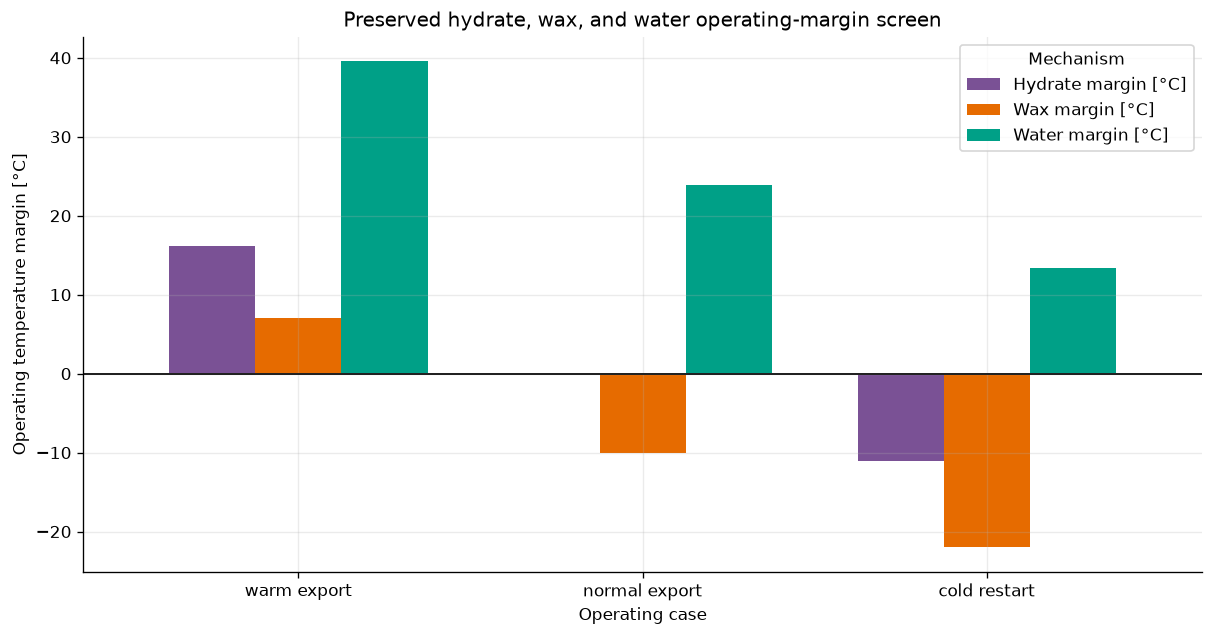

In [14]:
margin_columns = [
    "Hydrate margin [°C]",
    "Wax margin [°C]",
    "Water margin [°C]",
]
margin_colors = [
    "#7A5195",
    "#E66B00",
    "#00A087",
]

figure, axis = plt.subplots(figsize=(10.2, 5.4))
margin_table.set_index("Case")[margin_columns].plot(
    kind="bar",
    ax=axis,
    color=margin_colors,
    width=0.75,
)
axis.axhline(
    0.0,
    color="#222222",
    linewidth=1.2,
)
axis.set_title(
    "Preserved hydrate, wax, and water operating-margin screen"
)
axis.set_xlabel("Operating case")
axis.set_ylabel("Operating temperature margin [°C]")
axis.legend(
    title="Mechanism",
    loc="best",
)
axis.tick_params(
    axis="x",
    rotation=0,
)
plt.tight_layout()
plt.show()

**Interpretation.** Warm export is above all three thresholds. Normal export is nearly on the
hydrate boundary and below WAT. Cold restart is below both hydrate equilibrium and WAT but
remains above the trace-water dew point. This is precisely why one generic “cold margin” is
inadequate.

## 9. Pressure sensitivity

The next screen varies pressure from 40 to 100 bara while holding the composition and
mechanism-specific fluid bases fixed. This isolates thermodynamic pressure sensitivity; it
is not a pipeline temperature calculation.

In [15]:
pressure_grid_bara = np.arange(
    40.0,
    101.0,
    10.0,
)
threshold_rows = []

for pressure_bara in pressure_grid_bara:
    threshold_rows.append(
        {
            "Pressure [bara]": pressure_bara,
            "Hydrate equilibrium [°C]": (
                hydrate_temperature_c(pressure_bara)
            ),
            "Wax appearance [°C]": (
                wax_curve_result(pressure_bara)["wat_c"]
            ),
            "Water dew point [°C]": (
                water_dew_point_c(pressure_bara)
            ),
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
threshold_table

Out[15]: 
   Pressure [bara]  ...  Water dew point [°C]
0             40.0  ...            -11.479213
1             50.0  ...             -9.215154
2             60.0  ...             -7.393140
3             70.0  ...             -5.885873
4             80.0  ...             -4.614649
5             90.0  ...             -3.533820
6            100.0  ...             -2.609195

[7 rows x 4 columns]


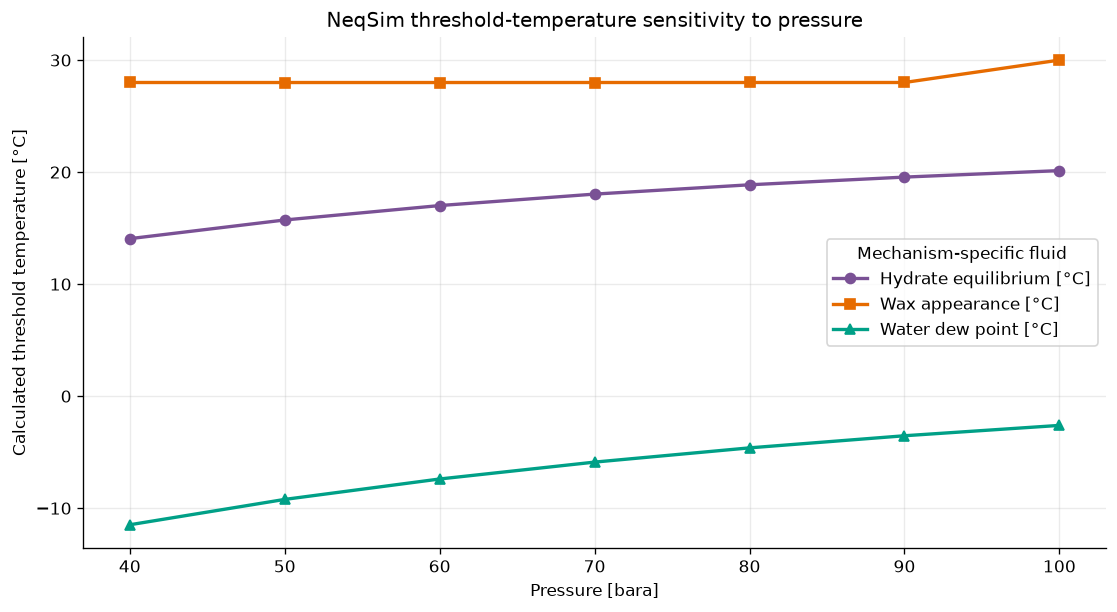

In [16]:
figure, axis = plt.subplots(figsize=(9.4, 5.2))

for column_name, color, marker in [
    (
        "Hydrate equilibrium [°C]",
        "#7A5195",
        "o",
    ),
    (
        "Wax appearance [°C]",
        "#E66B00",
        "s",
    ),
    (
        "Water dew point [°C]",
        "#00A087",
        "^",
    ),
]:
    axis.plot(
        threshold_table["Pressure [bara]"],
        threshold_table[column_name],
        color=color,
        marker=marker,
        linewidth=2.0,
        label=column_name,
    )

axis.set_title(
    "NeqSim threshold-temperature sensitivity to pressure"
)
axis.set_xlabel("Pressure [bara]")
axis.set_ylabel("Calculated threshold temperature [°C]")
axis.legend(
    title="Mechanism-specific fluid",
    loc="best",
)
plt.tight_layout()
plt.show()

Hydrate and water-dew-point temperatures rise with pressure over the screened range. The wax
threshold is comparatively insensitive to pressure for this gas-condensate basis. These
trends are model and composition dependent.

## 10. Hydrate risk along the preserved operating profile

`HydrateRiskMapper` is a current NeqSim flow-assurance class. It evaluates each
distance-pressure-temperature point, calculates hydrate equilibrium, assigns a risk class,
and exports JSON or CSV.

In [17]:
profile_fluid = build_hydrate_fluid(
    pressure_bara=80.0,
)
risk_mapper = HydrateRiskMapper(profile_fluid)

for operating_case in cases.itertuples(index=False):
    risk_mapper.addProfilePoint(
        float(operating_case.distance_km),
        float(operating_case.pressure_bara),
        float(operating_case.temperature_C),
    )

risk_profile = risk_mapper.calculate()
risk_profile_json = json.loads(
    str(risk_profile.toJson())
)
risk_profile_table = pd.DataFrame(
    risk_profile_json["profile"]
).rename(
    columns={
        "distance_km": "Distance [km]",
        "pressure_bara": "Pressure [bara]",
        "actualTemperature_C": "Actual temperature [°C]",
        "hydrateTemperature_C": "Hydrate temperature [°C]",
        "subcooling_C": "Hydrate margin [°C]",
        "riskLevel": "Risk level",
    }
)

risk_profile_table

Out[17]: 
   Distance [km]  Pressure [bara]  ...  Hydrate margin [°C]  Risk level
0            0.0             80.0  ...            16.132178         LOW
1           50.0             70.0  ...            -0.036903    CRITICAL
2          100.0             60.0  ...           -11.013888    CRITICAL

[3 rows x 6 columns]


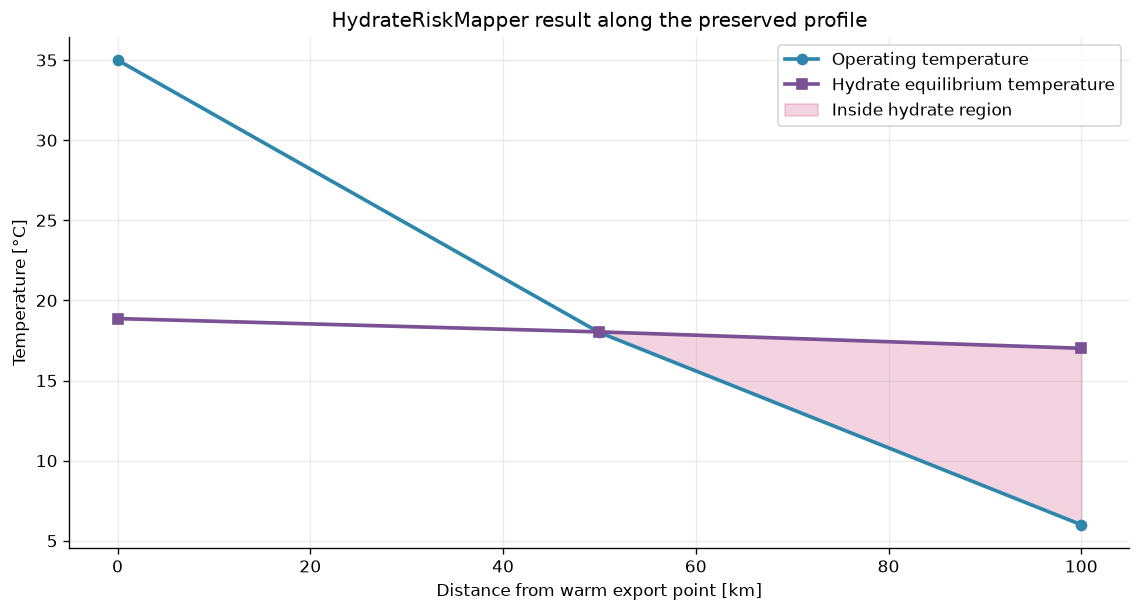

In [18]:
figure, axis = plt.subplots(figsize=(9.6, 5.2))
distance_km = risk_profile_table["Distance [km]"]
actual_temperature_c = risk_profile_table[
    "Actual temperature [°C]"
]
hydrate_temperature_profile_c = risk_profile_table[
    "Hydrate temperature [°C]"
]

axis.plot(
    distance_km,
    actual_temperature_c,
    color="#2E86AB",
    marker="o",
    linewidth=2.2,
    label="Operating temperature",
)
axis.plot(
    distance_km,
    hydrate_temperature_profile_c,
    color="#7A5195",
    marker="s",
    linewidth=2.2,
    label="Hydrate equilibrium temperature",
)
axis.fill_between(
    distance_km,
    actual_temperature_c,
    hydrate_temperature_profile_c,
    where=(
        actual_temperature_c
        < hydrate_temperature_profile_c
    ),
    color="#D45087",
    alpha=0.25,
    label="Inside hydrate region",
)
axis.set_title(
    "HydrateRiskMapper result along the preserved profile"
)
axis.set_xlabel("Distance from warm export point [km]")
axis.set_ylabel("Temperature [°C]")
axis.legend(loc="best")
plt.tight_layout()
plt.show()

The mapper classifies the normal and cold-restart points as critical. The minimum margin is
the cold-restart value. A real pipeline profile would use wall or bulk-fluid temperatures
from a hydraulic/thermal model rather than three illustrative points.

## 11. Wax fraction curves

WAT alone does not show how much solid wax is predicted below the onset. The retained
condensate is therefore flashed over temperature at 60, 70, and 80 bara.

In [19]:
wax_curve_rows = []

for pressure_bara in [60.0, 70.0, 80.0]:
    result = wax_curve_result(pressure_bara)

    for temperature_c, wax_fraction in zip(
        result["temperature_c"],
        result["wax_weight_fraction"],
    ):
        wax_curve_rows.append(
            {
                "Pressure [bara]": pressure_bara,
                "Temperature [°C]": temperature_c,
                "Wax fraction [wt%]": (
                    wax_fraction * 100.0
                ),
            }
        )

wax_curve_table = pd.DataFrame(wax_curve_rows)
wax_curve_table.groupby(
    "Pressure [bara]"
).agg(
    {
        "Wax fraction [wt%]": ["min", "max"],
        "Temperature [°C]": ["min", "max"],
    }
)

Out[19]: 
                Wax fraction [wt%]           Temperature [°C]      
                               min       max              min   max
Pressure [bara]                                                    
60.0                           0.0  0.114686            -30.0  50.0
70.0                           0.0  0.112058            -30.0  50.0
80.0                           0.0  0.111351            -30.0  50.0


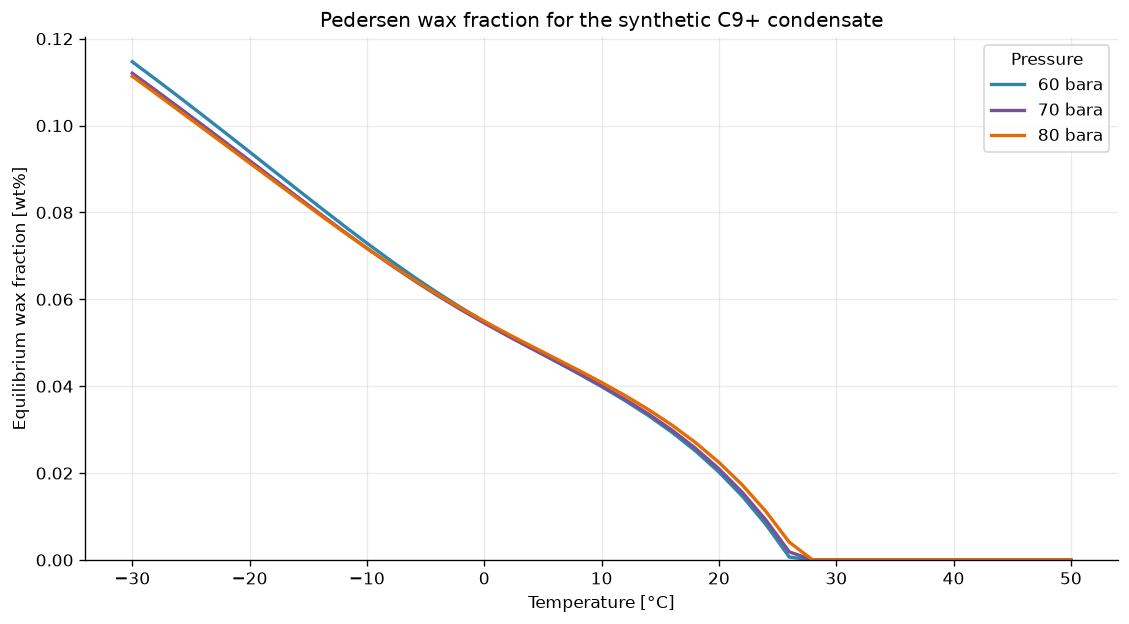

In [20]:
figure, axis = plt.subplots(figsize=(9.5, 5.3))
pressure_colors = {
    60.0: "#2E86AB",
    70.0: "#7A5195",
    80.0: "#E66B00",
}

for pressure_bara, group in wax_curve_table.groupby(
    "Pressure [bara]"
):
    ordered_group = group.sort_values(
        "Temperature [°C]"
    )
    axis.plot(
        ordered_group["Temperature [°C]"],
        ordered_group["Wax fraction [wt%]"],
        color=pressure_colors[pressure_bara],
        linewidth=2.0,
        label=f"{pressure_bara:.0f} bara",
    )

axis.set_title(
    "Pedersen wax fraction for the synthetic C9+ condensate"
)
axis.set_xlabel("Temperature [°C]")
axis.set_ylabel("Equilibrium wax fraction [wt%]")
axis.legend(
    title="Pressure",
    loc="best",
)
axis.set_ylim(bottom=0.0)
plt.tight_layout()
plt.show()

The predicted wax fraction rises monotonically as temperature falls. Pressure has a small
effect for this basis. Deposition remains a coupled heat-transfer and mass-transfer problem;
equilibrium wax fraction is an inventory indicator, not a wall-deposition rate.

## 12. Water-content sensitivity

Water dew point depends strongly on gas water content. The ISO calculation is repeated at
70 bara from 20 to 120 µmol/mol without changing the dry-gas composition.

In [21]:
water_content_grid = np.asarray(
    [
        20.0,
        40.0,
        60.0,
        80.0,
        120.0,
    ]
)
water_sensitivity_rows = []

for water_content in water_content_grid:
    water_sensitivity_rows.append(
        {
            "Water content [µmol/mol]": water_content,
            "Water dew point at 70 bara [°C]": (
                water_dew_point_c(
                    70.0,
                    water_umol_per_mol=water_content,
                )
            ),
        }
    )

water_sensitivity_table = pd.DataFrame(
    water_sensitivity_rows
)
water_sensitivity_table

Out[21]: 
   Water content [µmol/mol]  Water dew point at 70 bara [°C]
0                      20.0                       -15.927842
1                      40.0                       -10.032935
2                      60.0                        -5.885873
3                      80.0                        -2.745159
4                     120.0                         2.034834


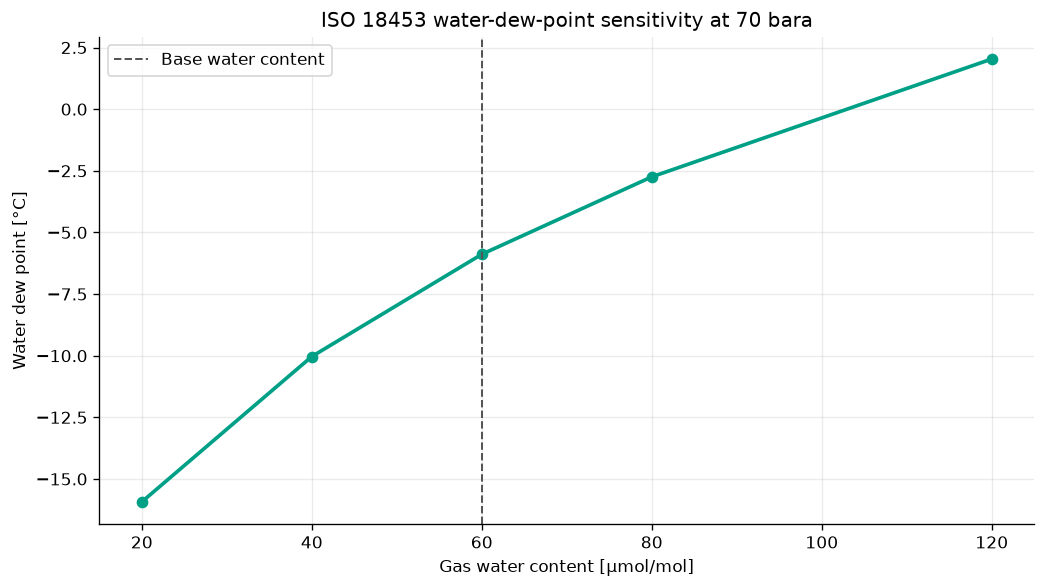

In [22]:
figure, axis = plt.subplots(figsize=(8.8, 5.0))
axis.plot(
    water_sensitivity_table[
        "Water content [µmol/mol]"
    ],
    water_sensitivity_table[
        "Water dew point at 70 bara [°C]"
    ],
    color="#00A087",
    marker="o",
    linewidth=2.2,
)
axis.axvline(
    60.0,
    color="#555555",
    linestyle="--",
    linewidth=1.2,
    label="Base water content",
)
axis.set_title(
    "ISO 18453 water-dew-point sensitivity at 70 bara"
)
axis.set_xlabel("Gas water content [µmol/mol]")
axis.set_ylabel("Water dew point [°C]")
axis.legend(loc="best")
plt.tight_layout()
plt.show()

Higher water content raises the dew point. Contract limits, sampling uncertainty, analyser
bias, and pressure corrections should be propagated before using a single calculated value
as an operating limit.

## 13. Practical NeqSim application: cold-restart decision support

The final section composes actual NeqSim objects:

1. a wet-gas `Stream` at the cold-restart condition;
2. a `HydrateEquilibriumTemperatureAnalyser`;
3. a `ProcessSystem` execution;
4. a hydrate-phase flash at the same condition;
5. an MEG equilibrium-dose calculation;
6. a reusable machine-readable decision report.

In [23]:
restart_fluid = build_hydrate_fluid(
    pressure_bara=60.0,
    temperature_c=6.0,
)
restart_stream = Stream(
    "Cold restart gas",
    restart_fluid,
)
restart_stream.setFlowRate(
    10_000.0,
    "kg/hr",
)
restart_stream.setTemperature(
    6.0,
    "C",
)
restart_stream.setPressure(
    60.0,
    "bara",
)

hydrate_analyser = HydrateAnalyser(
    "Hydrate equilibrium analyser",
    restart_stream,
)
hydrate_analyser.setReferencePressure(60.0)

restart_process = ProcessSystem()
restart_process.add(restart_stream)
restart_process.add(hydrate_analyser)
restart_process.run()

analyser_temperature_c = (
    hydrate_analyser.getMeasuredValue("C")
)
restart_status = json.loads(
    str(
        restart_process.getAutomation().getRunStatusJson()
    )
)

pd.DataFrame(
    {
        "Quantity": [
            "Operating temperature",
            "Hydrate equilibrium temperature",
            "Hydrate margin",
            "Process run success",
        ],
        "Value": [
            6.0,
            analyser_temperature_c,
            6.0 - analyser_temperature_c,
            restart_status["success"],
        ],
        "Unit": [
            "°C",
            "°C",
            "°C",
            "-",
        ],
    }
)

Out[23]: 
                          Quantity      Value Unit
0            Operating temperature        6.0   °C
1  Hydrate equilibrium temperature  17.013888   °C
2                   Hydrate margin -11.013888   °C
3              Process run success       True    -


The analyser clones the stream fluid before calculating equilibrium, so it does not overwrite
the process stream temperature. This is useful for online screening and digital-twin
calculations.

In [24]:
hydrate_flash_fluid = build_hydrate_fluid(
    pressure_bara=60.0,
    temperature_c=6.0,
)
hydrate_flash_operations = ThermodynamicOperations(
    hydrate_flash_fluid
)
hydrate_flash_operations.hydrateTPflash()

phase_rows = []

for phase_index in range(
    hydrate_flash_fluid.getNumberOfPhases()
):
    phase_rows.append(
        {
            "Phase index [-]": phase_index,
            "Phase type": str(
                hydrate_flash_fluid
                .getPhase(phase_index)
                .getType()
            ),
            "Phase mole fraction [-]": (
                hydrate_flash_fluid.getBeta(
                    phase_index
                )
            ),
        }
    )

hydrate_phase_table = pd.DataFrame(phase_rows)
hydrate_phase_table

Out[24]: 
   Phase index [-] Phase type  Phase mole fraction [-]
0                0        GAS                 0.937810
1                1    AQUEOUS                 0.027998
2                2    HYDRATE                 0.034192


At 6 °C and 60 bara the equilibrium flash contains gas, aqueous, and hydrate phases. The
hydrate phase fraction is an equilibrium result for the specified free-water basis; it is
not a prediction of blockage time or deposited volume in a real line.

In [25]:
inhibited_fluid = SystemSrkCPA(
    273.15 + 6.0,
    60.0,
)

for component_name, mole_fraction in gas_composition.items():
    inhibited_fluid.addComponent(
        component_name,
        mole_fraction,
    )

inhibited_fluid.addComponent("water", 0.08)
inhibited_fluid.addComponent("MEG", 0.02)
inhibited_fluid.setMixingRule(10)
inhibited_fluid.setHydrateCheck(True)

inhibitor_operations = ThermodynamicOperations(
    inhibited_fluid
)
inhibitor_operations.hydrateInhibitorConcentration(
    "MEG",
    273.15 + 6.0,
)

aqueous_meg_weight_percent = (
    inhibited_fluid
    .getPhase("aqueous")
    .getWtFrac("MEG")
    * 100.0
)
inhibited_equilibrium_temperature_c = (
    inhibited_fluid.getTemperature("C")
)

pd.DataFrame(
    {
        "Quantity": [
            "Target hydrate equilibrium temperature",
            "Calculated equilibrium temperature",
            "Aqueous MEG concentration",
        ],
        "Value": [
            6.0,
            inhibited_equilibrium_temperature_c,
            aqueous_meg_weight_percent,
        ],
        "Unit": [
            "°C",
            "°C",
            "wt%",
        ],
    }
)

Out[25]: 
                                 Quantity      Value Unit
0  Target hydrate equilibrium temperature   6.000000   °C
1      Calculated equilibrium temperature   5.999406   °C
2               Aqueous MEG concentration  33.336908  wt%


The MEG result is the aqueous-phase equilibrium concentration needed to shift the hydrate
boundary to the operating temperature for this synthetic fluid. A design dose must add
uncertainty, minimum free-water inventory, dilution, losses, regeneration performance,
distribution, and an operational safety margin.

In [26]:
base_restart_margin_c = (
    6.0 - analyser_temperature_c
)
heated_restart_temperature_c = 20.0
heated_restart_margin_c = (
    heated_restart_temperature_c
    - analyser_temperature_c
)
meg_equilibrium_margin_c = (
    6.0 - inhibited_equilibrium_temperature_c
)

mitigation_table = pd.DataFrame(
    {
        "Scenario": [
            "Unmitigated restart",
            "Heat or insulate to 20 °C",
            "MEG equilibrium target at 6 °C",
        ],
        "Operating temperature [°C]": [
            6.0,
            heated_restart_temperature_c,
            6.0,
        ],
        "Hydrate boundary [°C]": [
            analyser_temperature_c,
            analyser_temperature_c,
            inhibited_equilibrium_temperature_c,
        ],
        "Thermodynamic margin [°C]": [
            base_restart_margin_c,
            heated_restart_margin_c,
            meg_equilibrium_margin_c,
        ],
    }
)
mitigation_table

Out[26]: 
                         Scenario  ...  Thermodynamic margin [°C]
0             Unmitigated restart  ...                 -11.013888
1       Heat or insulate to 20 °C  ...                   2.986112
2  MEG equilibrium target at 6 °C  ...                   0.000594

[3 rows x 4 columns]


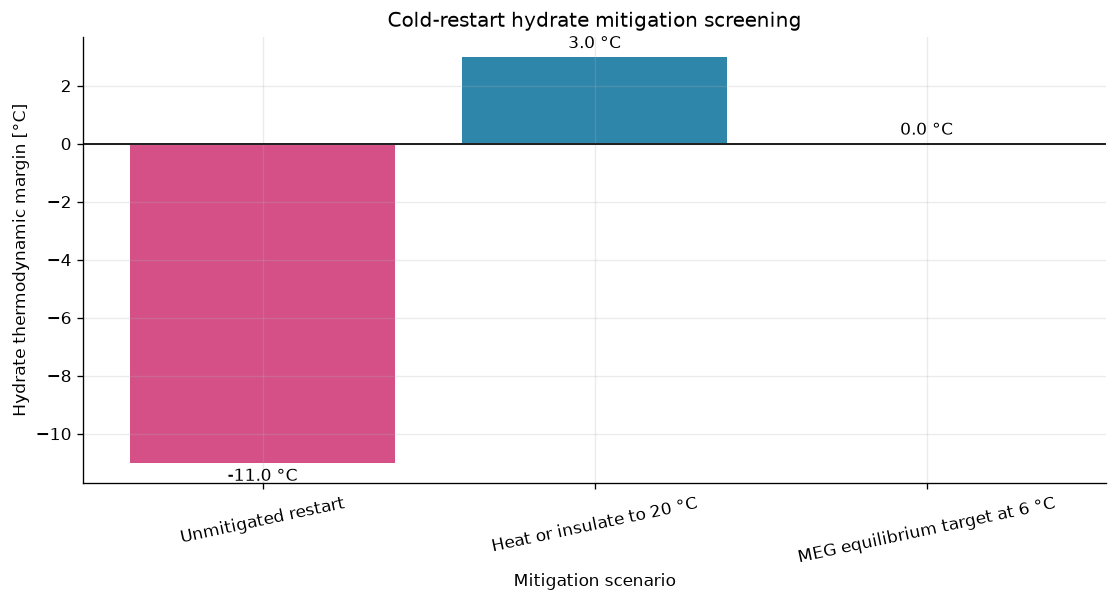

In [27]:
figure, axis = plt.subplots(figsize=(9.4, 5.1))
mitigation_colors = [
    "#D45087",
    "#2E86AB",
    "#00A087",
]
bars = axis.bar(
    mitigation_table["Scenario"],
    mitigation_table["Thermodynamic margin [°C]"],
    color=mitigation_colors,
)
axis.axhline(
    0.0,
    color="#222222",
    linewidth=1.2,
)
axis.bar_label(
    bars,
    fmt="%.1f °C",
    padding=3,
)
axis.set_title(
    "Cold-restart hydrate mitigation screening"
)
axis.set_xlabel("Mitigation scenario")
axis.set_ylabel("Hydrate thermodynamic margin [°C]")
axis.tick_params(
    axis="x",
    rotation=12,
)
plt.tight_layout()
plt.show()

Heating creates a positive thermodynamic margin. The calculated MEG concentration moves the
equilibrium boundary to the operating temperature and therefore has essentially zero design
allowance; a real design must target a lower equilibrium temperature.

In [28]:
decision_report = {
    "schema_version": "1.0",
    "case_fingerprint": case_fingerprint,
    "neqsim_version": importlib.metadata.version("neqsim"),
    "cold_restart": {
        "pressure_bara": 60.0,
        "temperature_C": 6.0,
        "hydrate_equilibrium_C": analyser_temperature_c,
        "hydrate_margin_C": base_restart_margin_c,
        "hydrate_phase_fraction": (
            hydrate_flash_fluid.getHydrateFraction()
        ),
        "water_dew_point_C": water_dew_point_c(60.0),
        "wax_appearance_C": (
            wax_curve_result(60.0)["wat_c"]
        ),
    },
    "mitigation_screen": {
        "heated_temperature_C": (
            heated_restart_temperature_c
        ),
        "heated_margin_C": heated_restart_margin_c,
        "aqueous_MEG_weight_percent": (
            aqueous_meg_weight_percent
        ),
        "MEG_equilibrium_target_C": (
            inhibited_equilibrium_temperature_c
        ),
    },
    "process_run_status": restart_status,
    "limits": (
        "Equilibrium screening only; add kinetics, uncertainty, "
        "transport, heat transfer, and operating safeguards."
    ),
}

print(
    json.dumps(
        decision_report,
        indent=2,
    )
)

{
  "schema_version": "1.0",
  "case_fingerprint": "82589e1f718e00109b0f06bb5285d4093919bda7589644569286132236468634",
  "neqsim_version": "3.16.0",
  "cold_restart": {
    "pressure_bara": 60.0,
    "temperature_C": 6.0,
    "hydrate_equilibrium_C": 17.013888229153167,
    "hydrate_margin_C": -11.013888229153167,
    "hydrate_phase_fraction": 0.034191642043056136,
    "water_dew_point_C": -7.393140478811631,
    "wax_appearance_C": 27.997036024184222
  },
  "mitigation_screen": {
    "heated_temperature_C": 20.0,
    "heated_margin_C": 2.9861117708468328,
    "aqueous_MEG_weight_percent": 33.3369076522709,
    "MEG_equilibrium_target_C": 5.999406218756803
  },
  "process_run_status": {
    "schemaVersion": "1.0",
    "completed": true,
    "success": true,
    "failedUnitName": null,
    "failedUnitError": null,
    "unitCount": 1,
    "units": [
      {
        "unitName": "Cold restart gas",
        "unitType": "Stream",
        "success": true,
        "errorMessage": null
      }


## 14. Verification checks

The checks below test inputs, trends, independent API paths, flash closure, the preserved
cases and figure logic, and the final mitigation application. They are deliberately focused
on properties that should remain true if the notebook is rerun.

In [29]:
wax_monotonic_checks = []

for pressure_bara in [60.0, 70.0, 80.0]:
    wax_fractions = wax_curve_result(
        pressure_bara
    )["wax_weight_fraction"]
    wax_monotonic_checks.append(
        np.all(
            np.diff(wax_fractions) >= -1.0e-12
        )
    )

phase_fraction_sum = hydrate_phase_table[
    "Phase mole fraction [-]"
].sum()

checks = {
    "composition normalized": math.isclose(
        sum(gas_composition.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "fingerprint has 64 characters": (
        len(case_fingerprint) == 64
    ),
    "original case names preserved": (
        cases["case"].tolist()
        == [
            "warm export",
            "normal export",
            "cold restart",
        ]
    ),
    "original pressures preserved": (
        cases["pressure_bara"].tolist()
        == [80.0, 70.0, 60.0]
    ),
    "original temperatures preserved": (
        cases["temperature_C"].tolist()
        == [35.0, 18.0, 6.0]
    ),
    "gas densities finite": np.isfinite(
        density_table["Gas density [kg/m³]"]
    ).all(),
    "gas densities positive": (
        density_table["Gas density [kg/m³]"] > 0.0
    ).all(),
    "hydrate results finite": np.isfinite(
        hydrate_table[
            "Hydrate equilibrium temperature [°C]"
        ]
    ).all(),
    "hydrate temperature rises with pressure": (
        threshold_table[
            "Hydrate equilibrium [°C]"
        ].is_monotonic_increasing
    ),
    "warm hydrate margin positive": (
        margin_table.loc[
            margin_table["Case"] == "warm export",
            "Hydrate margin [°C]",
        ].iloc[0]
        > 0.0
    ),
    "cold hydrate margin negative": (
        margin_table.loc[
            margin_table["Case"] == "cold restart",
            "Hydrate margin [°C]",
        ].iloc[0]
        < 0.0
    ),
    "water dew points finite": np.isfinite(
        water_table["Water dew point [°C]"]
    ).all(),
    "water dew point rises with pressure": (
        threshold_table[
            "Water dew point [°C]"
        ].is_monotonic_increasing
    ),
    "cold water margin positive": (
        margin_table.loc[
            margin_table["Case"] == "cold restart",
            "Water margin [°C]",
        ].iloc[0]
        > 0.0
    ),
    "wax results finite": np.isfinite(
        wax_table["Wax appearance temperature [°C]"]
    ).all(),
    "wax flashes all succeeded": (
        wax_table["Failed flashes [-]"] == 0
    ).all(),
    "warm wax margin positive": (
        margin_table.loc[
            margin_table["Case"] == "warm export",
            "Wax margin [°C]",
        ].iloc[0]
        > 0.0
    ),
    "cold wax margin negative": (
        margin_table.loc[
            margin_table["Case"] == "cold restart",
            "Wax margin [°C]",
        ].iloc[0]
        < 0.0
    ),
    "wax curves are monotonic": all(
        wax_monotonic_checks
    ),
    "wax fractions nonnegative": (
        wax_curve_table["Wax fraction [wt%]"] >= 0.0
    ).all(),
    "risk mapper returns three points": (
        len(risk_profile_table) == 3
    ),
    "risk mapper finds two critical points": (
        risk_profile.getCriticalPointCount() == 2
    ),
    "risk mapper minimum margin matches cold case": (
        abs(
            risk_profile.getMinimumSubcoolingC()
            - margin_table.loc[
                margin_table["Case"] == "cold restart",
                "Hydrate margin [°C]",
            ].iloc[0]
        )
        < 1.0e-8
    ),
    "water content raises dew point": (
        water_sensitivity_table[
            "Water dew point at 70 bara [°C]"
        ].is_monotonic_increasing
    ),
    "process execution succeeded": (
        restart_status["success"] is True
    ),
    "analyser agrees with direct hydrate calculation": (
        abs(
            analyser_temperature_c
            - hydrate_temperature_c(60.0)
        )
        < 1.0e-8
    ),
    "hydrate phase is present": (
        hydrate_flash_fluid.hasHydratePhase()
    ),
    "hydrate phase fraction positive": (
        hydrate_flash_fluid.getHydrateFraction() > 0.0
    ),
    "hydrate phase fractions close": math.isclose(
        phase_fraction_sum,
        1.0,
        abs_tol=1.0e-10,
    ),
    "MEG result finite": math.isfinite(
        aqueous_meg_weight_percent
    ),
    "MEG concentration bounded": (
        0.0 < aqueous_meg_weight_percent < 100.0
    ),
    "MEG equilibrium target met": (
        abs(
            inhibited_equilibrium_temperature_c
            - 6.0
        )
        < 0.05
    ),
    "heating improves margin": (
        heated_restart_margin_c
        > base_restart_margin_c
    ),
    "report fingerprint matches": (
        decision_report["case_fingerprint"]
        == case_fingerprint
    ),
}

failed_checks = [
    check_name
    for check_name, passed in checks.items()
    if not passed
]
assert not failed_checks, failed_checks

print(
    f"All {len(checks)} engineering checks passed."
)
pd.DataFrame(
    {
        "Check": list(checks),
        "Passed": list(checks.values()),
    }
)

All 34 engineering checks passed.
Out[29]: 
                                              Check  Passed
0                            composition normalized    True
1                     fingerprint has 64 characters    True
2                     original case names preserved    True
3                      original pressures preserved    True
4                   original temperatures preserved    True
5                              gas densities finite    True
6                            gas densities positive    True
7                            hydrate results finite    True
8           hydrate temperature rises with pressure    True
9                      warm hydrate margin positive    True
10                     cold hydrate margin negative    True
11                          water dew points finite    True
12              water dew point rises with pressure    True
13                       cold water margin positive    True
14                               wax results finite    T

## Troubleshooting

- **Hydrate calculation fails:** verify that water is present, mixing rule 10 is used, and
  `setHydrateCheck(True)` is called before the operation.
- **Wax phase is missing:** characterize the plus fraction, call `addTBPWax()`, select the wax
  model before adding the wax phase, and enable multiphase wax checking.
- **Water dew point is implausible:** check that water content uses molar fraction
  (`µmol/mol × 10⁻⁶`) and pressure is absolute.
- **Repeated results depend on order:** construct a fresh fluid or clone for each pressure
  and temperature point.
- **MEG result is used for design:** stop and add free-water inventory, dilution, uncertainty,
  transport, regeneration, and operational allowance.

## Limitations and applicability

This notebook supports early screening and workflow development. It does not replace:

- validated PVT and wax laboratory data;
- inhibitor performance and compatibility testing;
- transient thermal-hydraulic simulation;
- wax deposition, hydrate growth, or restart kinetics;
- wall-temperature, terrain, slugging, and shutdown-history analysis;
- uncertainty propagation, safeguards, or operating-procedure review.

Treat the three fluid bases as explicit scenarios. Do not combine their phase inventories or
interpret the wax and hydrate fractions as simultaneous phases of one uncalibrated fluid.

## Summary

The original three-case margin screen is now backed by current NeqSim functionality:

- SRK properties preserve the original gas example;
- SRK-CPA calculates hydrate equilibrium and hydrate phase formation;
- ISO 18453 calculates trace-water dew point;
- Pedersen characterization and `WaxCurveCalculator` calculate WAT and wax curves;
- `HydrateRiskMapper` classifies the operating profile;
- a `ProcessSystem` hydrate analyser and MEG calculation support a practical restart screen.

Positive margin means the operating temperature is warmer than the calculated threshold.
Engineering acceptance still requires uncertainty, kinetics, transport, and safeguards.

## Further exercises

1. Replace the synthetic gas and condensate with a documented laboratory composition.
2. Add pressure and temperature uncertainty bands to each margin.
3. Compare Pedersen, Won, Wilson, and Coutinho wax models for discrete n-alkane data.
4. Couple the hydrate profile to a NeqSim pipeline thermal calculation.
5. Add methanol and MEG dilution scenarios with a minimum 3 °C design allowance.
6. Export the risk profile CSV and decision JSON to a governed engineering workflow.

## Authoritative references

- [NeqSim flow-assurance overview](https://equinor.github.io/neqsim/pvtsimulation/flow_assurance_overview.html)
- [NeqSim hydrate flash operations](https://equinor.github.io/neqsim/thermodynamicoperations/hydrate_flash_operations.html)
- [NeqSim wax characterization and modeling](https://equinor.github.io/neqsim/thermo/characterization/wax_characterization.html)
- [NeqSim process simulation documentation](https://equinor.github.io/neqsim/process/)
- [Current NeqSim PyPI release](https://pypi.org/project/neqsim/)
- ISO 18453, *Natural gas — Correlation between water content and water dew point*.
- Pedersen, K. S., Skovborg, P., and Rønningsen, H. P. (1991),
  *Energy & Fuels*, 5, 924–932.